In [10]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [11]:
filename = "replan_@MAEDeR_maze-128-128-1-even-1-k50_2026-06-04-11-57_seed123_25delays_CRCfsippUpdate"
filepath = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "output", "maze1", f"{filename}.json")
complete_result = {
    "@MAEDeR": json.load(open(filepath, "r")),
    "FlexSIPP": json.load(open(filepath.replace("@MAEDeR", "FlexSIPP"), "r"))
}

## Process

In [12]:
df = pd.DataFrame(columns=["Delay Idx", "Delay Agent", "Delayed Starttime", "Delay Amount", "Cumulative Delay", "Total FlexSIPP" ,"Total @MAEDeR", "Fail FlexSIPP", "Fail @MAEDeR"])
rows = 0
paths = {
    "FlexSIPP": {a: [r["arrival"][1]]  for a, r in complete_result["FlexSIPP"]["delay0"]["initial_paths"].items()},
    "@MAEDeR": {a: [r["arrival"][1]]  for a, r in complete_result["@MAEDeR"]["delay0"]["initial_paths"].items()}
}
delays = ["" for a in complete_result["FlexSIPP"]["delay0"]["initial_paths"]]
cumulative_delay = 0
for delay in complete_result["FlexSIPP"]:
    for a, r in complete_result["FlexSIPP"][delay]["arrival_times"].items():
        paths["FlexSIPP"][a].append(r["arrival"][1])
    for a, r in complete_result["@MAEDeR"][delay]["arrival_times"].items():
        paths["@MAEDeR"][a].append(r["arrival"][1])
    delays[int(complete_result["FlexSIPP"][delay]["delay_agent"])-1] = str(complete_result["FlexSIPP"][delay]["delay_agent"])
    assert complete_result["FlexSIPP"][delay]["delay_agent"] == complete_result["@MAEDeR"][delay]["delay_agent"]
    cumulative_delay += (complete_result["FlexSIPP"][delay]["delayed_start_time"] - complete_result["FlexSIPP"][delay]["original_start_time"])
    df.loc[rows] = [
        delay,
        complete_result["FlexSIPP"][delay]["delay_agent"],
        complete_result["FlexSIPP"][delay]["delayed_start_time"],
        complete_result["FlexSIPP"][delay]["delayed_start_time"] - complete_result["FlexSIPP"][delay]["original_start_time"],
        cumulative_delay,
        sum([(paths["FlexSIPP"][a][-1] - paths["FlexSIPP"][a][0]) for a in paths["FlexSIPP"]]),
        sum([(paths["@MAEDeR"][a][-1] - paths["@MAEDeR"][a][0]) for a in paths["@MAEDeR"]]),
        not (complete_result["FlexSIPP"][delay] and complete_result["FlexSIPP"][delay]["unique_routes_safe"]),
        not (complete_result["@MAEDeR"][delay] and complete_result["@MAEDeR"][delay]["unique_routes_safe"]),
    ]
    rows += 1

In [13]:
print("@MAEDeR failed", len(df[df["Fail @MAEDeR"]]), "times and FlexSIPP failed", len(df[df["Fail FlexSIPP"]]), "times")

@MAEDeR failed 6 times and FlexSIPP failed 3 times


#### Print individual differences per agent MAEDeR and FlexSIPP

In [14]:
print("\t\t@MAEDEr FLexSIPP")
for a in paths["FlexSIPP"]:
    print("Agent", a, "\t", paths["@MAEDeR"][a][-1] - paths["@MAEDeR"][a][0],"\t", paths["FlexSIPP"][a][-1] - paths["FlexSIPP"][a][0])
print("Agent", a, "\t", 
    sum([(paths["@MAEDeR"][a][-1] - paths["@MAEDeR"][a][0]) for a in paths["FlexSIPP"]]),"\t", 
    sum([(paths["FlexSIPP"][a][-1] - paths["FlexSIPP"][a][0]) for a in paths["@MAEDeR"]])
)

		@MAEDEr FLexSIPP
Agent 1 	 0 	 0
Agent 2 	 -16 	 -16
Agent 3 	 0 	 1
Agent 4 	 0 	 0
Agent 5 	 111 	 38
Agent 6 	 0 	 1
Agent 7 	 0 	 0
Agent 8 	 0 	 0
Agent 9 	 0 	 0
Agent 10 	 -1 	 0
Agent 11 	 0 	 1
Agent 12 	 186 	 115
Agent 13 	 7 	 1.5376167738406252
Agent 14 	 0 	 1.2128149999999778
Agent 15 	 95 	 -7
Agent 16 	 0 	 1
Agent 17 	 1 	 1
Agent 18 	 0 	 0
Agent 19 	 -1 	 -1
Agent 20 	 0 	 0
Agent 21 	 1 	 0
Agent 22 	 0 	 1
Agent 23 	 57.31685145105314 	 57.31685145105314
Agent 24 	 0 	 1
Agent 25 	 0 	 2
Agent 26 	 1 	 -59
Agent 27 	 0 	 1
Agent 28 	 119 	 3.2128149999999778
Agent 29 	 0 	 0
Agent 30 	 -65 	 -33
Agent 31 	 27 	 26
Agent 32 	 0 	 0
Agent 33 	 1 	 -14
Agent 34 	 107 	 49
Agent 35 	 0 	 0
Agent 36 	 0 	 0
Agent 37 	 0 	 2
Agent 38 	 0 	 0.8240908526566102
Agent 39 	 0 	 3
Agent 40 	 0 	 0
Agent 41 	 0 	 0
Agent 42 	 0 	 0
Agent 43 	 0 	 1
Agent 44 	 0 	 0
Agent 45 	 1 	 0
Agent 46 	 65 	 60
Agent 47 	 0 	 18
Agent 48 	 291 	 289
Agent 49 	 0 	 1
Agent 50 	 0 	 2
Ag

In [15]:
type(df["Fail @MAEDeR"].unique()[0])

numpy.bool

In [16]:
compile_pgf = False
if compile_pgf:
	matplotlib.use("pgf")
	matplotlib.rcParams.update({
	    "pgf.texsystem": "pdflatex",
	    'font.family': 'serif',
	    'text.usetex': True,
	    "axes.formatter.use_mathtext": True
	})

## Show cumulative delay

/var/folders/_m/3bb3blkx3dlfhqpn6f_qgv1h0000gn/T/ipykernel_10358/1535856038.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=fonts)


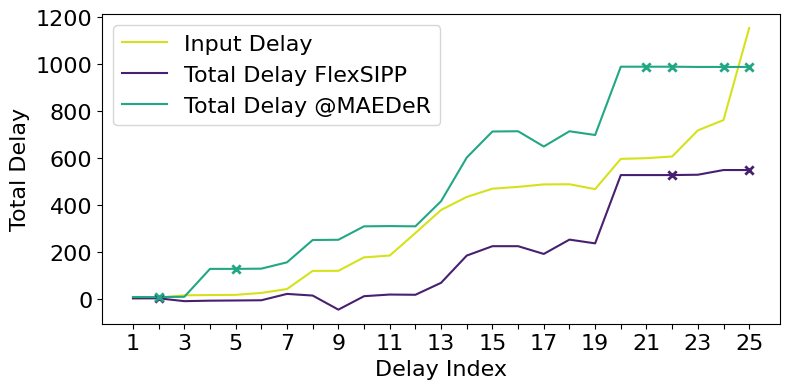

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))


colors = [
    (0.83527, 0.886029, 0.102646),
    (0.283187, 0.125848, 0.44496),
    (0.132268, 0.655014, 0.519661),
]

df.plot(ax=ax, x="Delay Idx", y="Cumulative Delay", label="Input Delay", color=colors[0])
df.plot(ax=ax, x="Delay Idx", y="Total FlexSIPP", label="Total Delay FlexSIPP", color=colors[1])
df.plot(ax=ax, x="Delay Idx", y="Total @MAEDeR", label="Total Delay @MAEDeR", color=colors[2])

ax.scatter(df.index[df['Fail FlexSIPP']], df.loc[df['Fail FlexSIPP'], 'Total FlexSIPP'], marker='x', color=colors[1], zorder=5, linewidth=2)
ax.scatter(df.index[df['Fail @MAEDeR']], df.loc[df['Fail @MAEDeR'], 'Total @MAEDeR'], marker='x', color=colors[2], zorder=5, linewidth=2)

ticks = [int(x.replace("delay", "")) + 1 if i % 2 == 0 else "" for i, x in enumerate(df["Delay Idx"].unique())]

fonts = 16

ax.set_xticks(range(len(df["Delay Idx"].unique())))
ax.set_xticklabels(ticks, fontsize=fonts)
ax.set_ylabel("Total Delay", fontsize=fonts)
ax.set_xlabel("Delay Index", fontsize=fonts)
ax.legend(fontsize=fonts)
ax.set_xlabel(ax.get_xlabel(), fontsize=fonts)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=fonts)
filepath = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "output", "sequential_delay_updates")
plt.tight_layout()
extension = "pgf" if compile_pgf else "png"
plt.savefig(f"{filepath}.{extension}", dpi=600)
plt.show()
plt.close()

### Plot the difference per agent

In [18]:
show_individual_diffs = False
if show_individual_diffs:
	fig, ax = plt.subplots(2,1, figsize=(8, 8))

	for num, alg in enumerate(paths):
		agents = []
		for i, (x, ys) in enumerate(paths[alg].items()):
			y_start = ys[0]
			y_end = ys[-1]
			y_min = min(ys)
			y_max = max(ys)

			# Draw the full range as a thin background line
			agents.append(x)
			ax[num].plot([i, i], [y_min, y_max], color="lightgray", linewidth=4, zorder=1)

			color = "gray"
			if str(x) in delays:
				color = "red"

			# Mark intermediate points
			for y in ys[1:-1]:
				ax[num].scatter(i, y, color=color, s=30, zorder=3)

			# Draw arrow from first to last value
			ax[num].annotate(
				"",
				xy=(i, y_end),
				xytext=(i, y_start),
				arrowprops=dict(arrowstyle="->", color="black", lw=2),
				zorder=2,
			)


		ax[num].set_xticks([int(x)-1 for x in agents])
		ax[num].set_xticklabels([str(x)  if i % 4 == 0 else "" for i,x in enumerate(agents)], fontsize=12)
		ax[num].set_xlabel("Agent", fontsize=12)
		ax[num].set_ylabel("Arrival Time", fontsize=12)
		ax[num].set_yticklabels(ax[num].get_yticklabels(), fontsize=12)
		ax[num].set_title(alg)
	plt.tight_layout()
	plt.savefig(f"{filepath}.png", dpi=600)
	plt.show()